In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

,0
Applicant_ID,50
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50


**Handel MIssing Value**

In [6]:
categorical_col = df.select_dtypes(include=["object"]).columns
categorical_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numeric_col = df.select_dtypes(include=["float64"]).columns
numeric_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
from sklearn.impute import SimpleImputer

In [9]:
# to fill the missimg value with mean in numeric col

num_imp =  SimpleImputer(strategy="mean")
df[numeric_col] = num_imp.fit_transform(df[numeric_col])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   950 non-null    object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [11]:
# to fill the missimg value with mode  in categorical col

cat_imp =  SimpleImputer(strategy="most_frequent")
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])

**EDA**

Text(0.5, 1.0, 'loan aprove class view')

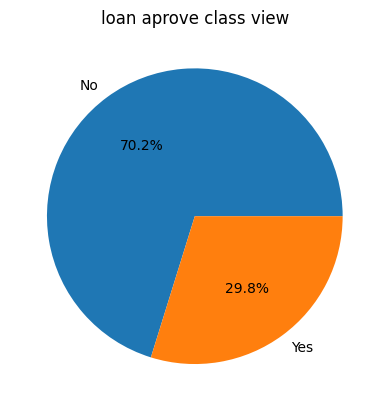

In [12]:
# how balanced our class
class_count = df['Loan_Approved'].value_counts()
plt.pie(class_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("loan aprove class view")

[Text(0, 0, '621'), Text(0, 0, '379')]

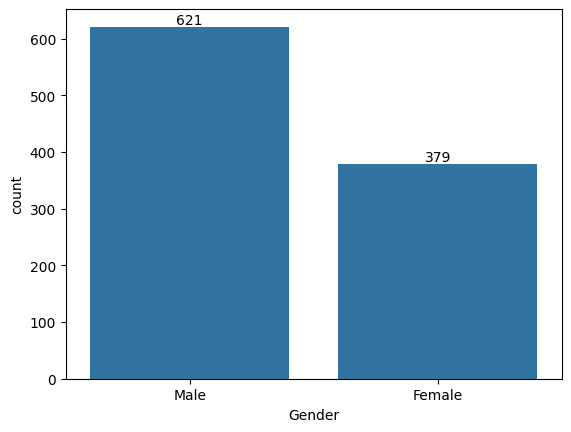

In [13]:
# gender analyze
gender_count = df["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

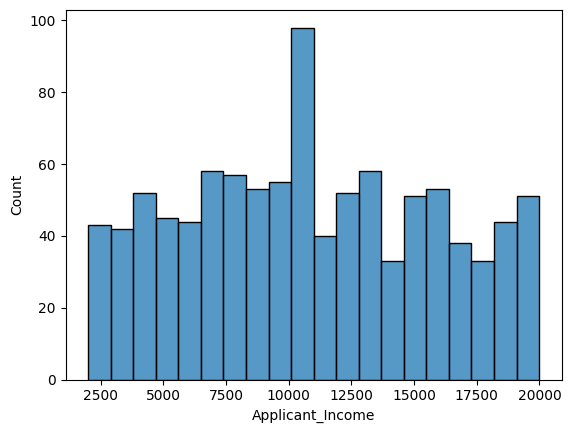

In [14]:
# analyze income
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

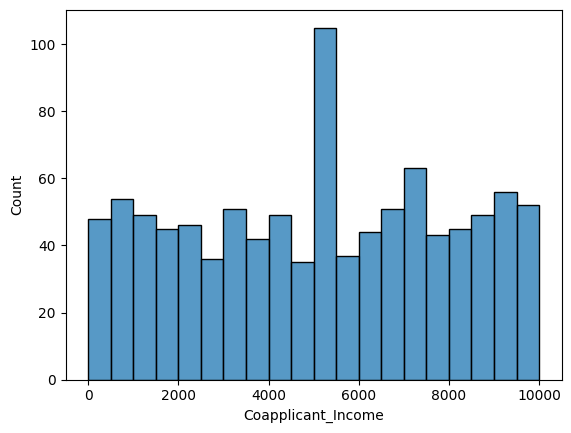

In [15]:
# analyze  co-applicant income
sns.histplot(
    data=df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

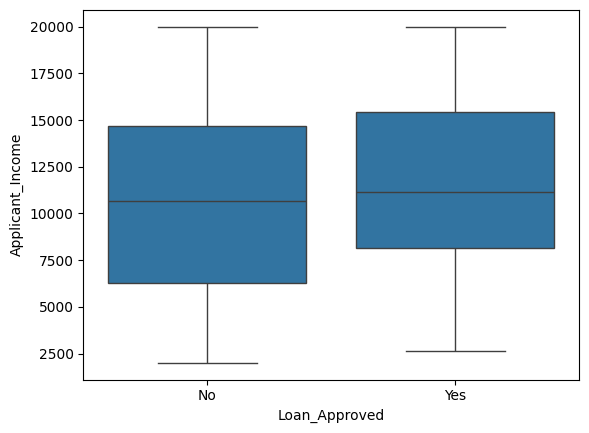

In [16]:
# detect out layesr

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

In [17]:
numeric_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

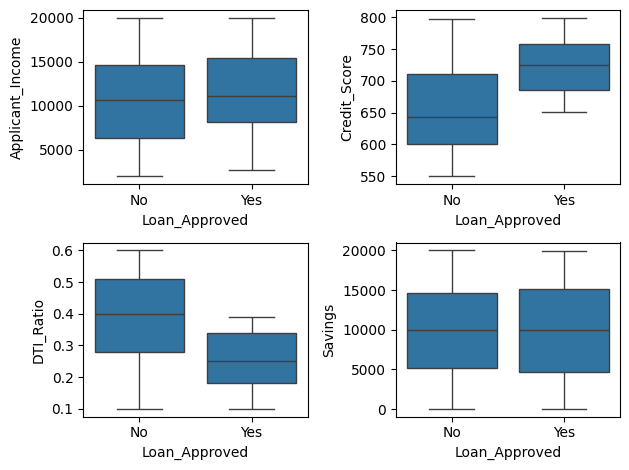

In [18]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df,x = "Loan_Approved",y = "Savings")
plt.tight_layout()


<Axes: xlabel='Credit_Score', ylabel='Count'>

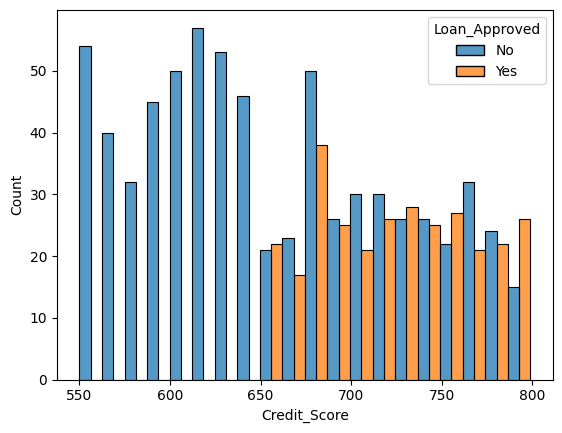

In [19]:
# relation of credit store with loan approved
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple="dodge"

)

In [20]:
# remove the applicant id
df = df.drop(columns=["Applicant_ID"], axis=1)

In [21]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


**Encode**

In [22]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [24]:
# label encoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df.head(3)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1


In [25]:
# one hot encoder
col = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[col])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(col), index = df.index )

df = pd.concat([df.drop(columns=col), encoded_df], axis=1)


In [26]:
df.head(5)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [27]:
# co relation heat map
num_col = df.select_dtypes(include="number")
corr_metrix = num_col.corr()
corr_metrix["Loan_Approved"].sort_values(ascending=False)

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.451175
Applicant_Income,0.119796
Employer_Category_MNC,0.069049
Loan_Purpose_Personal,0.034043
Marital_Status_Single,0.030182
Property_Area_Urban,0.025963
Collateral_Value,0.021868
Coapplicant_Income,0.004230
Loan_Purpose_Home,0.002118


<Axes: >

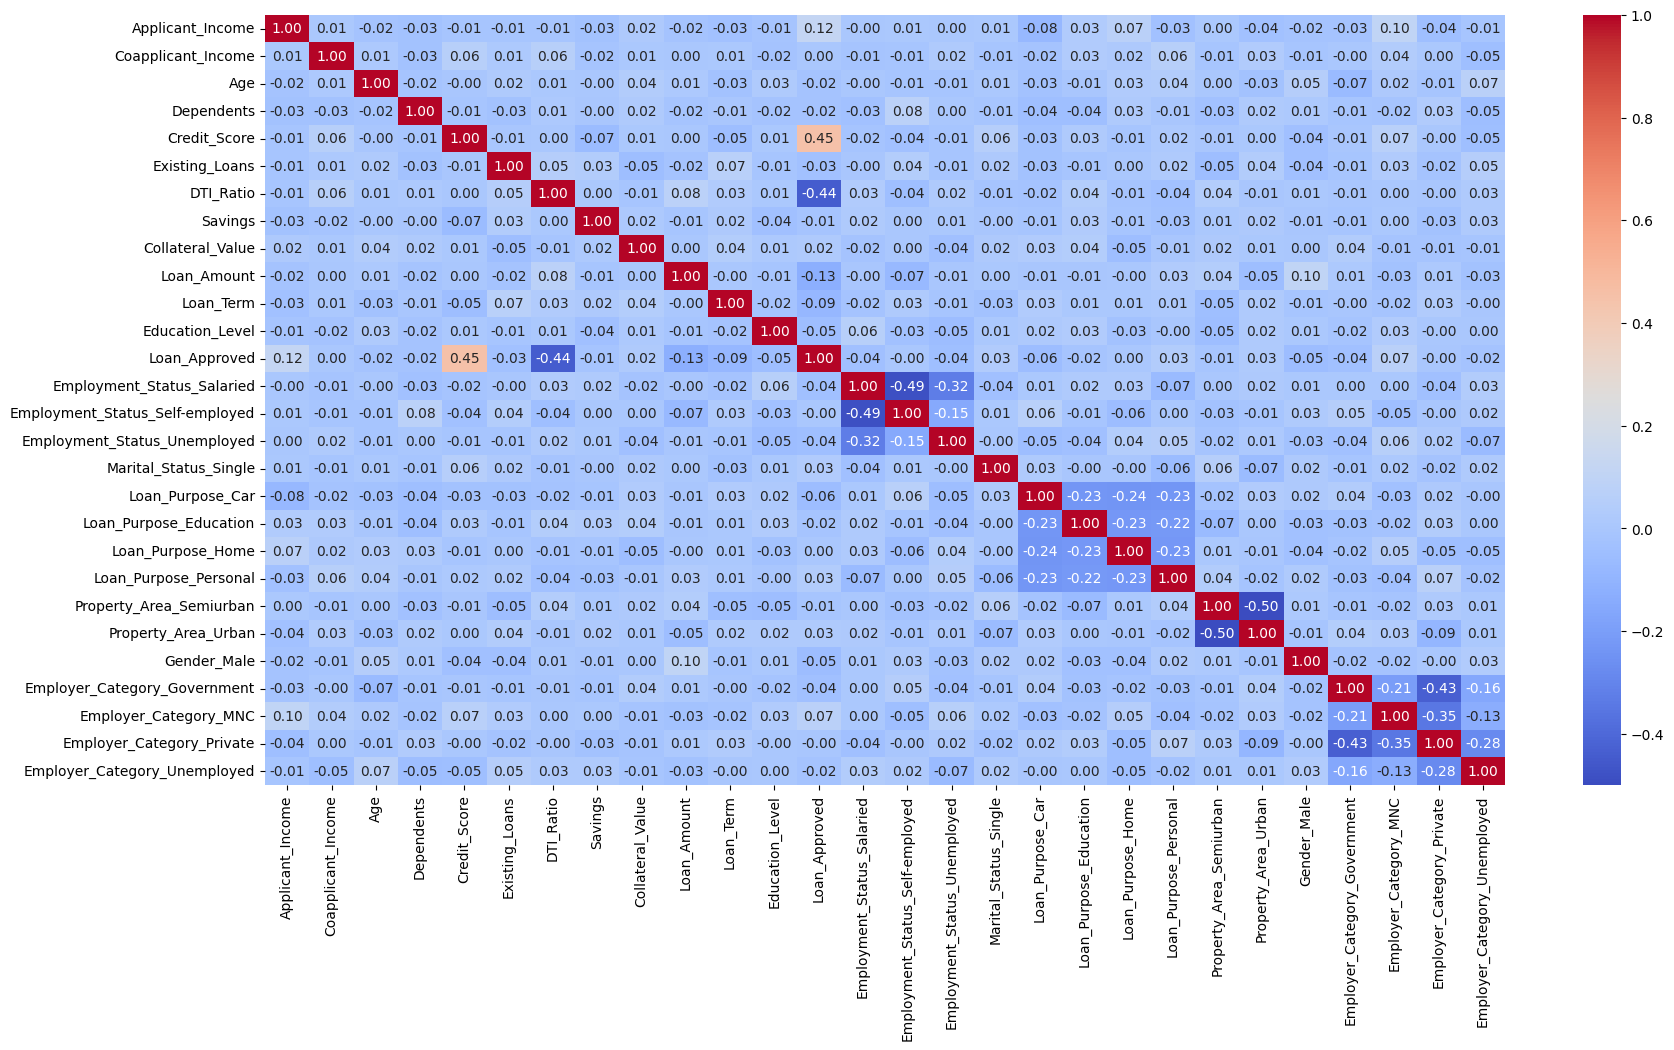

In [28]:
# to analyze the linear relation
plt.figure(figsize=(20, 10))
sns.heatmap(
    corr_metrix,
    annot=True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [29]:
#train test solit

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
X = df.drop(columns="Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [33]:
X_train

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.000000,603.000000,0.000000,0.110000,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.000000,614.000000,0.000000,0.210000,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.000000,584.000000,4.000000,0.220000,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.000000,726.000000,4.000000,0.340000,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.000000,676.033684,1.950526,0.180000,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,10755.000000,4107.0,59.000000,0.000000,560.000000,2.000000,0.347263,6806.0,5932.000000,20323.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
270,2569.000000,5068.0,39.971579,1.474737,673.000000,1.000000,0.530000,3563.0,21699.000000,12280.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
860,9783.000000,6099.0,31.000000,0.000000,703.000000,1.000000,0.347263,2575.0,48348.000000,26208.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
435,16512.000000,3762.0,53.000000,1.000000,616.000000,1.000000,0.320000,14780.0,3598.000000,23191.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [34]:
# scaling data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [36]:
X_test_scaled

array([[ 0.49894288,  0.57374582,  1.24349235, ..., -0.39505615,
         1.19959343, -0.40347329],
       [ 1.1005236 ,  0.61287645,  0.19941775, ..., -0.39505615,
         1.19959343, -0.40347329],
       [-0.63666026, -0.52505619,  1.14857648, ..., -0.39505615,
         1.19959343, -0.40347329],
       ...,
       [-0.64102557, -0.07959591,  1.33840823, ..., -0.39505615,
         1.19959343, -0.40347329],
       [-0.32838652, -0.95863752, -0.55990923, ..., -0.39505615,
        -0.83361577, -0.40347329],
       [-0.69943752, -1.22591369,  0.76891299, ..., -0.39505615,
         1.19959343, -0.40347329]])

**train and evaluate mode**

In [40]:
# loistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#evaluation
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score

print("precission",precision_score(y_test, y_pred))
print("recall_score",recall_score(y_test, y_pred))
print("f1_score",f1_score(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion_matrix \n ",confusion_matrix(y_test, y_pred))



precission 0.8518518518518519
recall_score 0.7540983606557377
f1_score 0.8
accuracy_score 0.885
confusion_matrix 
  [[131   8]
 [ 15  46]]


In [41]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

#evaluation
print("precission",precision_score(y_test, y_pred))
print("recall_score",recall_score(y_test, y_pred))
print("f1_score",f1_score(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion_matrix \n ",confusion_matrix(y_test, y_pred))


precission 0.6086956521739131
recall_score 0.45901639344262296
f1_score 0.5233644859813084
accuracy_score 0.745
confusion_matrix 
  [[121  18]
 [ 33  28]]


In [43]:
# Naive_bayes
from sklearn.naive_bayes import GaussianNB

Naive_bayes_model = GaussianNB()
Naive_bayes_model.fit(X_train_scaled, y_train)

y_pred = Naive_bayes_model.predict(X_test_scaled)

#evaluation
print("precission",precision_score(y_test, y_pred))
print("recall_score",recall_score(y_test, y_pred))
print("f1_score",f1_score(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion_matrix \n ",confusion_matrix(y_test, y_pred))

precission 0.7777777777777778
recall_score 0.6885245901639344
f1_score 0.7304347826086957
accuracy_score 0.845
confusion_matrix 
  [[127  12]
 [ 19  42]]
